In [23]:
from stress_risk.utils.data import get_all_behavior
from tms_risk.utils.data import Subject as TMSSubject
import pandas as pd
import seaborn as sns

In [24]:
# sub 01 - > sub-32
df_tms = TMSSubject('01').get_behavior()
order = df_tms.index.names
df_tms = df_tms.reset_index('subject')
df_tms['subject'] = 32
df_tms = df_tms.set_index('subject', append=True).reorder_levels(order)

In [25]:
df = get_all_behavior()
df = pd.concat((df, df_tms))

/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_46022/3842034007.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  data=df.groupby(['subject', 'n_safe', 'risky_first']).mean().reset_index(), kind='point', ci=67)
/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_46022/3842034007.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 67)` for the same effect.

  sns.catplot(x='n_safe', y='chose_risky', hue='risky_first',


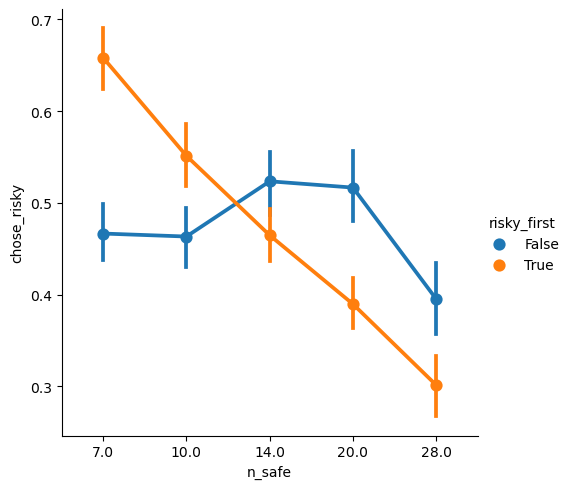

In [29]:
sns.catplot(x='n_safe', y='chose_risky', hue='risky_first',
data=df.groupby(['subject', 'n_safe', 'risky_first']).mean().reset_index(), kind='point', ci=67)

In [30]:
import bambi

In [31]:
df['x'] = df['log(risky/safe)']

In [33]:
model = bambi.Model('chose_risky ~ x + (x|subject)', link='probit', family='bernoulli', data=df.reset_index())

In [34]:
traces = model.fit()

Modeling the probability that chose_risky==1
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, x, 1|subject_sigma, 1|subject_offset, x|subject_sigma, x|subject_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 597 seconds.
The chain reached the maximum tree depth. Increase max_treedepth, increase target_accept or reparameterize.
The acceptance probability does not match the target. It is 0.7115, but should be close to 0.8. Try to increase the number of tuning steps.
The chain reached the maximum tree depth. Increase max_treedepth, increase target_accept or reparameterize.


In [35]:
import scipy.stats as ss
def invprobit(x):
    return ss.norm.ppf(x)

In [36]:
def extract_rnp_precision(trace, model, data, group=False):

    data = data.reset_index()

    if group:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique()[[0]],
                                                [0, 1],
                                                data['n_safe'].unique(),
                                                [False, True]],
                                                names=['subject', 'x', 'n_safe', 'risky_first']
                                                ).to_frame().reset_index(drop=True)
    else:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique(),
                                                [0, 1],
                                                data['n_safe'].unique(),
                                                [False, True]],
                                                names=['subject', 'x', 'n_safe', 'risky_first']
                                                ).to_frame().reset_index(drop=True)

    pred = model.predict(trace, 'mean', fake_data, inplace=False)['posterior']['chose_risky_mean']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred

    pred0 = pred.xs(0, 0, 'x')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

    return intercept, gamma

In [37]:
import arviz as az

In [ ]:
az.plot_trace(